✅ 2D Asset kaydedildi: ../../../assets\46_heat_2d.png


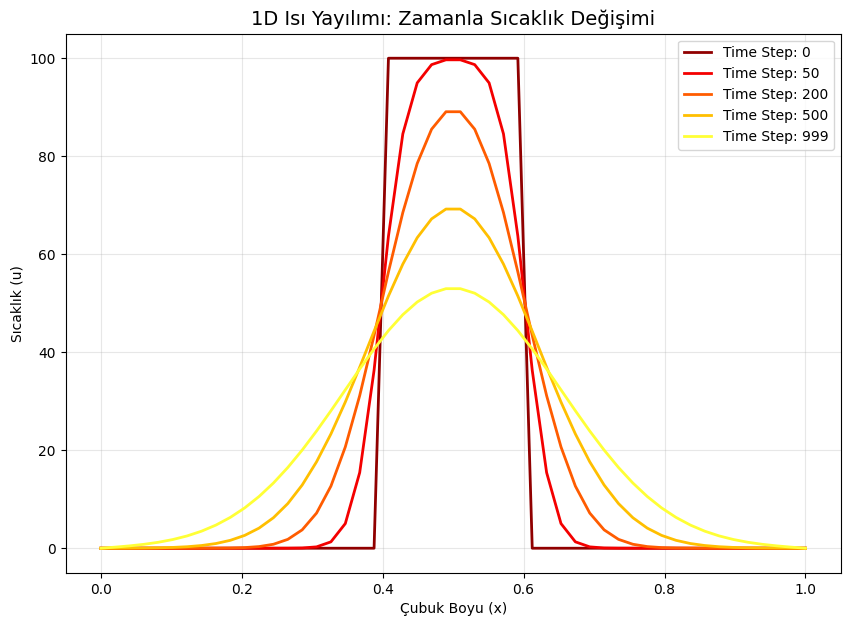

✅ 3D Asset kaydedildi: ../../../assets\46_heat_3d.png


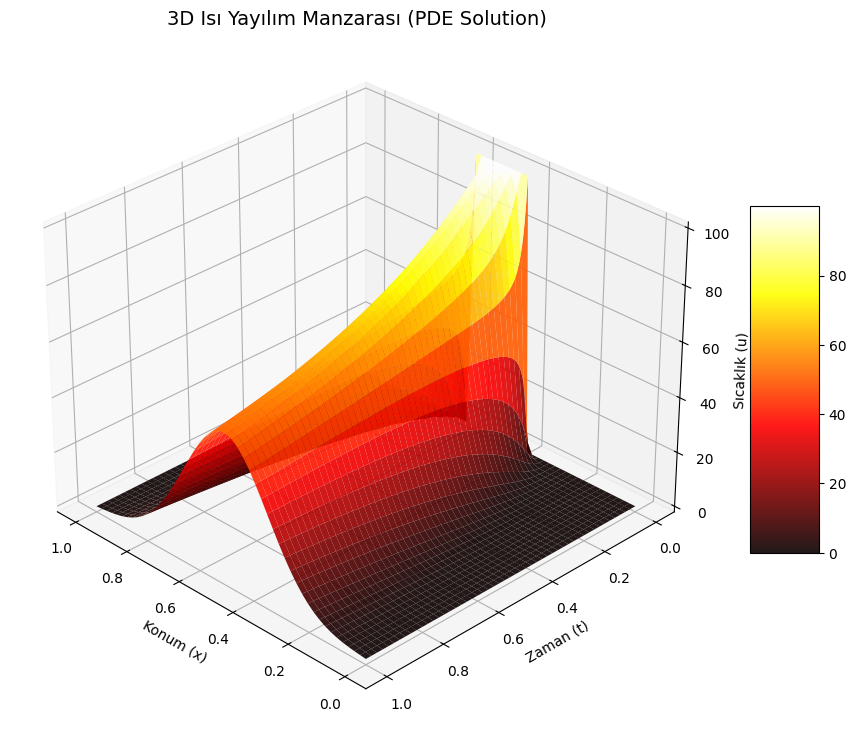

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import os

def run_heat_equation_master():
    # --- 🎯 SENİN YOLUN (FIXED ASSET PATH) ---
    asset_path = r'../../../assets'
    if not os.path.exists(asset_path):
        os.makedirs(asset_path)

    # 1. Simülasyon Parametreleri
    L = 1.0        # Çubuğun boyu
    nx = 50        # Uzay adımı sayısı
    dx = L / (nx - 1)
    alpha = 0.01   # Isıl yayılım katsayısı
    dt = 0.001     # Zaman adımı (Stabilite için küçük seçilmeli)
    nt = 1000      # Toplam zaman adımı

    # Başlangıç Koşulu: Çubuğun ortasında bir sıcaklık piki (Delta function approximation)
    u = np.zeros(nx)
    u[int(0.4*nx):int(0.6*nx)] = 100.0 # Orta kısım 100 derece
    
    # Tüm veriyi saklamak için matris (3D için)
    u_history = np.zeros((nt, nx))
    u_history[0, :] = u.copy()

    # 2. Sayısal Çözüm (Finite Difference Method)
    for t in range(1, nt):
        un = u.copy()
        for i in range(1, nx - 1):
            # Isı denklemi ayrıklaştırma (FTCS Method)
            u[i] = un[i] + alpha * dt / dx**2 * (un[i+1] - 2*un[i] + un[i-1])
        u_history[t, :] = u.copy()

    # --- 📸 ASSET 1: 2D TEMPERATURE PROFILES (46_heat_2d.png) ---
    fig1 = plt.figure(figsize=(10, 7))
    time_snapshots = [0, 50, 200, 500, 999]
    colors = plt.cm.hot(np.linspace(0.2, 0.8, len(time_snapshots)))
    
    for i, t_idx in enumerate(time_snapshots):
        plt.plot(np.linspace(0, L, nx), u_history[t_idx, :], 
                 color=colors[i], lw=2, label=f'Time Step: {t_idx}')
    
    plt.title("1D Isı Yayılımı: Zamanla Sıcaklık Değişimi", fontsize=14)
    plt.xlabel("Çubuk Boyu (x)"); plt.ylabel("Sıcaklık (u)")
    plt.legend(); plt.grid(alpha=0.3)
    
    plt.savefig(os.path.join(asset_path, '46_heat_2d.png'), dpi=300)
    print(f"✅ 2D Asset kaydedildi: {asset_path}\\46_heat_2d.png")
    plt.show()

    # --- 📸 ASSET 2: 3D SPACE-TIME SURFACE (46_heat_3d.png) ---
    fig2 = plt.figure(figsize=(12, 9))
    ax3d = fig2.add_subplot(111, projection='3d')
    
    X = np.linspace(0, L, nx)
    T = np.linspace(0, nt*dt, nt)
    X_mesh, T_mesh = np.meshgrid(X, T)

    surf = ax3d.plot_surface(X_mesh, T_mesh, u_history, cmap='hot', alpha=0.9, edgecolor='none')
    
    ax3d.set_title("3D Isı Yayılım Manzarası (PDE Solution)", fontsize=14)
    ax3d.set_xlabel('Konum (x)'); ax3d.set_ylabel('Zaman (t)'); ax3d.set_zlabel('Sıcaklık (u)')
    fig2.colorbar(surf, ax=ax3d, shrink=0.5, aspect=5)
    
    # Açıyı daha iyi bir görüş için ayarla
    ax3d.view_init(elev=30, azim=135)

    plt.savefig(os.path.join(asset_path, '46_heat_3d.png'), dpi=300)
    print(f"✅ 3D Asset kaydedildi: {asset_path}\\46_heat_3d.png")
    plt.show()

if __name__ == "__main__":
    run_heat_equation_master()
